# Tarea 67 - Identificación de caras con DLIB

Aplicación de consola que cargue esa base de datos e intenta identificar las caras presentes

La salida deberá escribir los nombres de las personas que fue capaz de indentificar y el número de personas que no fue capaz de ponerle el nombre

In [79]:
import cv2
from matplotlib import pyplot as plt

## DLIB

**Dlib** es un framework en C++ para IA que incluye herramientas para la detección y identificación de caras

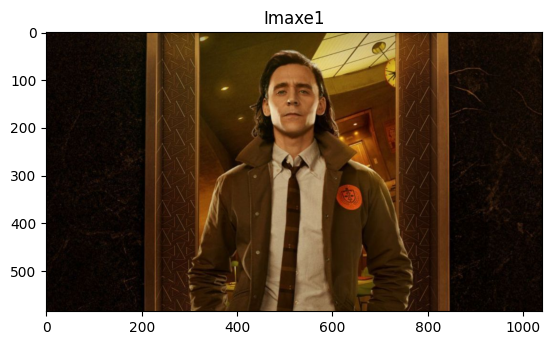

In [80]:
image = cv2.imread("img/Loki.jpg")
imaxe_color = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(imaxe_color)
plt.title('Imaxe1')
plt.show()

Para trabajar con el detector de caras es preciso descargar:
- Un sistema para predecir la forma de posición de la cara: http://dlib.net/files/shape_predictor_5_face_landmarks.dat.bz2
- Una RNA para identificar la cara: http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2

In [81]:
import dlib
import numpy as np

predictor_path ="modelos/shape_predictor_5_face_landmarks.dat"
face_rec_model_path = "modelos/dlib_face_recognition_resnet_model_v1.dat"


detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor(predictor_path)
facerec = dlib.face_recognition_model_v1(face_rec_model_path)


known_face_encodings = []
known_face_names = []

- Detectar a presenza de caras, chamando a **detector**
    - **detector** vai devolver un array cos rectángulos onde se detectou algo
- Para cada cara detectada:
    - Predecir a forma: chamdno ao **shape_predictor**, que antes se definiu como **sp**
    - Obter a firma da cara a partires da forma: chamar face_recognition_model_v1, definido como **facerec**

In [82]:
imaxePhill = cv2.imread("img/Loki.jpg")
imaxePhillColor = cv2.cvtColor(imaxePhill, cv2.COLOR_BGR2RGB)

dets = detector(imaxePhill, 1)
print("Number of faces detected: {}".format(len(dets)))
posicions = dets[0]
display(posicions)
shape = sp(imaxePhill,posicions)

# Vector que se guarda para la cara conocida
face_descriptor = np.array(facerec.compute_face_descriptor(imaxePhill, shape))
display(face_descriptor)

known_face_encodings.append((face_descriptor,"Loki"))

Number of faces detected: 1


rectangle(462,92,569,199)

array([-2.07966659e-02,  1.32065669e-01,  8.35936666e-02, -4.10287306e-02,
       -8.06896165e-02, -1.73652228e-02, -1.60699598e-02, -1.15684733e-01,
        1.46648556e-01, -3.27374600e-02,  1.90741837e-01, -2.16839369e-04,
       -2.32620209e-01,  8.34507868e-02, -2.28753723e-02,  8.13403204e-02,
       -1.45684317e-01, -1.38786569e-01, -1.21226937e-01, -3.83222550e-02,
        3.75848799e-03,  9.38193798e-02,  2.34239828e-02,  1.70431603e-02,
       -1.85875252e-01, -1.84011891e-01, -9.73358005e-02, -1.49771914e-01,
       -1.79006308e-02, -1.23660140e-01,  2.65730824e-03,  3.80370058e-02,
       -2.14009479e-01, -1.00058779e-01,  5.43539003e-02, -2.45976336e-02,
       -8.06447342e-02, -6.52301088e-02,  2.15436563e-01,  9.47124362e-02,
       -1.81967258e-01,  4.99106310e-02,  1.18363038e-01,  3.07428271e-01,
        1.78694457e-01,  3.43303569e-02, -2.59628352e-02, -1.76076815e-02,
        9.12538767e-02, -2.57853955e-01,  1.49831384e-01,  9.92220119e-02,
        1.92009822e-01,  

## Solución Tarea 67:

### Importar librerias y modelos

In [83]:
import pandas as pd
import os
import dlib
import numpy as np

predictor_path ="modelos/shape_predictor_5_face_landmarks.dat"
face_rec_model_path = "modelos/dlib_face_recognition_resnet_model_v1.dat"

detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor(predictor_path)
facerec = dlib.face_recognition_model_v1(face_rec_model_path)

### Obtener vector de la cara 

In [84]:
def obtenerVectorCaraImagen(img):
    dets = detector(img, 1)
    
    # Pequeña protección por si en la foto no se detecta ninguna cara
    if len(dets) == 0:
        print("No se detectó ninguna cara en la imagen.")
        return None
        
    print("Number of faces detected: {}".format(len(dets)))
    posicions = dets[0]
    display(posicions)
    
    shape = sp(img, posicions)

    face_descriptor = np.array(facerec.compute_face_descriptor(img, shape))
    #display(face_descriptor) # Comentamos para que no nos salga el troncho del vector por pantalla, descomentar si lo queremos ver
    return face_descriptor

### Guardar en csv: Vector y nombre de la cara

In [85]:
def guardarVectorCaraConNombre(nombre, face_descriptor):
    fingerprint_str = ",".join(face_descriptor.astype(str))
    
    nuevo_dato = pd.DataFrame(data={'nome': [nombre], 'fingerprint': [fingerprint_str]})
    
    # Comprobar si archivo existe
    if os.path.isfile('carasConocidas.csv'):
        # Leemos la base de datos actual
        df_existente = pd.read_csv('carasConocidas.csv')
        
        # Si el nombre ya está en la columna 'nome', paramos la función
        if nombre in df_existente['nome'].values:
            print(f"La cara de '{nombre}' ya existe. Se omite el guardado.")
            return
            
        # Si el archivo existe pero el nombre es nuevo, lo añadimos
        nuevo_dato.to_csv('carasConocidas.csv', mode='a', header=False, index=False)
    else:
        # Si el archivo no existe, lo creamos desde cero con sus cabeceras
        nuevo_dato.to_csv('carasConocidas.csv', index=False)
        
    print(f"Vector de '{nombre}' guardado correctamente en formato Pandas.")       

### Caras a guardar en csv

In [86]:
# Creamos una lista con las parejas de datos: (ruta_de_la_imagen, Nombre_de_la_persona)
caras_a_guardar = [
    ("img/Loki.jpg", "Loki"),
    ("img/Ted_Mosby.jpg", "Ted Mosby"),
    ("img/Barney.jpg", "Barney Stinson"),
    ("img/Robin.jpg", "Robin "),
    ("img/Alyson.jpg", "Alyson"),
    ("img/Marshall.jpeg", "Marshall")    
]

# Recorremos la lista automáticamente
for ruta, nombre in caras_a_guardar:
    img = cv2.imread(ruta)
    
    # Pequeña comprobación de seguridad por si la imagen no carga bien
    if img is not None:
        vector = obtenerVectorCaraImagen(img)
        
        # Solo guardamos si la función realmente encontró una cara en la foto
        if vector is not None:
            guardarVectorCaraConNombre(nombre, vector)
    else:
        print(f"Error: No se pudo cargar la imagen en la ruta '{ruta}'")

Number of faces detected: 1


rectangle(462,92,569,199)

La cara de 'Loki' ya existe. Se omite el guardado.
Number of faces detected: 1


rectangle(408,133,562,288)

La cara de 'Ted Mosby' ya existe. Se omite el guardado.
Number of faces detected: 1


...

La cara de 'Robin ' ya existe. Se omite el guardado.
Number of faces detected: 1


rectangle(613,613,1763,1764)

Vector de 'Alyson' guardado correctamente en formato Pandas.
Number of faces detected: 1


rectangle(53,82,182,211)

Vector de 'Marshall' guardado correctamente en formato Pandas.


### Leer dataset por el csv

In [87]:
leido = pd.read_csv("carasConocidas.csv")
display(leido)
# Creamos nueva columna obteniendo el numpy formateado
leido["f2"] = leido.apply(lambda row: np.array(row['fingerprint'].split(',')).astype(np.float64), axis=1)

,nome,fingerprint
0,Loki,"-0.02079666592180729,0.13206566870212555,0.083..."
1,Ted Mosby,"-0.14289340376853943,0.09137463569641113,0.092..."
2,Barney Stinson,"-0.07934118062257767,0.1230844035744667,0.0429..."
3,Robin,"-0.14987052977085114,0.2139454036951065,0.1450..."
4,Alyson,"-0.04498700425028801,0.11766504496335983,0.140..."
5,Marshall,"-0.17072446644306183,0.13376304507255554,0.004..."


In [88]:
display(leido)

,nome,fingerprint,f2
0,Loki,"-0.02079666592180729,0.13206566870212555,0.083...","[-0.02079666592180729, 0.13206566870212555, 0...."
1,Ted Mosby,"-0.14289340376853943,0.09137463569641113,0.092...","[-0.14289340376853943, 0.09137463569641113, 0...."
2,Barney Stinson,"-0.07934118062257767,0.1230844035744667,0.0429...","[-0.07934118062257767, 0.1230844035744667, 0.0..."
3,Robin,"-0.14987052977085114,0.2139454036951065,0.1450...","[-0.14987052977085114, 0.2139454036951065, 0.1..."
4,Alyson,"-0.04498700425028801,0.11766504496335983,0.140...","[-0.04498700425028801, 0.11766504496335983, 0...."
5,Marshall,"-0.17072446644306183,0.13376304507255554,0.004...","[-0.17072446644306183, 0.13376304507255554, 0...."


### Detección y clasificación de caras

In [89]:
def identificar_y_dibujar_caras(imagen_rgb, base_datos_pandas, tolerancia=0.60):
    face_names = []
    dets = detector(imagen_rgb, 0)
    
    # Bucle para buscar y comparar cada cara de la foto
    for d in dets:
        shape = sp(imagen_rgb, d)
        vector_desconocido = np.array(facerec.compute_face_descriptor(imagen_rgb, shape))

        matches = [] # Lista temporal para guardar las coincidencias de esta cara
        
        # Comparamos con cada persona de la base de datos
        for index, fila in base_datos_pandas.iterrows():
            nombre_conocido = fila['nome']
            vector_conocido = fila['f2']        
            
            # Calculamos la distancia
            distancia = np.linalg.norm(vector_conocido - vector_desconocido)

            if distancia <= tolerancia:
                matches.append((distancia, nombre_conocido))
        
        print(f"Posibles coincidencias para esta cara: {matches}")
        
        if len(matches) == 0:
            face_names.append(((d.top(), d.right(), d.bottom(), d.left()), "NonSei"))
        else:
            carasOrdenadas = sorted(matches, key=lambda x: x[0])
            mejor_nombre = carasOrdenadas[0][1]
            face_names.append(((d.top(), d.right(), d.bottom(), d.left()), mejor_nombre))

    # Bucle para dibujar los rectángulos en la imagen
    imaxeConMarcas = imagen_rgb.copy() 
    
    for (top, right, bottom, left), name in face_names:
        color = (0, 255, 0) 
        if name == "NonSei":
            color = (0, 0, 255)
            
        cv2.rectangle(imaxeConMarcas, (left, top), (right, bottom), color, 2)
        cv2.rectangle(imaxeConMarcas, (left, bottom + 20), (right, bottom), (0,0,0), cv2.FILLED)
        font = cv2.FONT_HERSHEY_DUPLEX
        cv2.putText(imaxeConMarcas, name, (left + 6, bottom + 15), font, 0.5, (255, 255, 255), 1)

    # 3. Mostrar el resultado final
    plt.imshow(imaxeConMarcas)
    plt.title('Caras atopadas')
    plt.show()
    
    # Devolvemos la lista de nombres por si quieres usarla para otra cosa en el programa
    return face_names

Posibles coincidencias para esta cara: [(np.float64(0.5879353830051984), 'Ted Mosby')]
Posibles coincidencias para esta cara: [(np.float64(0.4130196795250442), 'Marshall')]
Posibles coincidencias para esta cara: [(np.float64(0.4428796763688712), 'Alyson')]
Posibles coincidencias para esta cara: [(np.float64(0.4480740125495562), 'Robin ')]
Posibles coincidencias para esta cara: [(np.float64(0.43459000294152345), 'Barney Stinson')]
Posibles coincidencias para esta cara: []


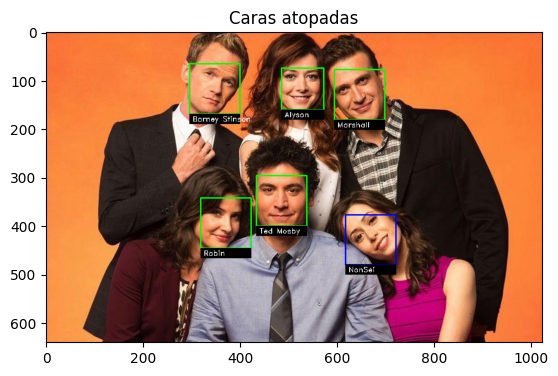

Posibles coincidencias para esta cara: [(np.float64(0.4972802742573784), 'Robin ')]
Posibles coincidencias para esta cara: [(np.float64(0.4870145655281942), 'Alyson')]
Posibles coincidencias para esta cara: [(np.float64(0.4597382398874293), 'Marshall')]
Posibles coincidencias para esta cara: [(np.float64(0.5865043873470344), 'Ted Mosby')]
Posibles coincidencias para esta cara: [(np.float64(0.45204937602582984), 'Barney Stinson')]


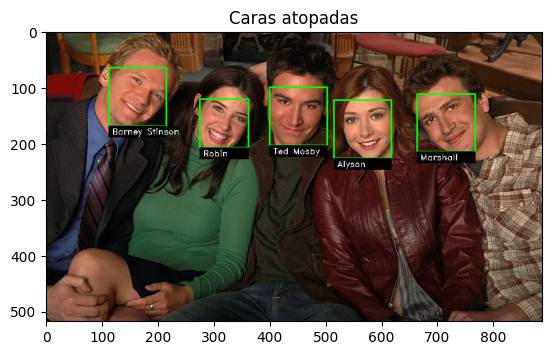

In [90]:
# Las imagenes que queramos detectar, si no queremos, si lo queremos hacer solo en una utilizamos la función creada 'identificar_y_dibujar_caras'
img_detectar = [
    ("img/comoConociAVuestraMadre.jpg"),
    ("img/allOther.jpg")
]

# Recorremos la lista automáticamente
for ruta in img_detectar:
    img = cv2.imread(ruta)
    
    # Pequeña comprobación de seguridad por si la imagen no carga bien
    if img is not None:
        imgColor = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Solo guardamos si la función realmente encontró una cara en la foto
        if imgColor is not None:
            faces = identificar_y_dibujar_caras(imgColor, leido)
    else:
        print(f"Error: No se pudo cargar la imagen en la ruta '{ruta}'")